#**Análisis de las lluvias en Australia**

##**1. Presentación de dataset**

Este data set presenta datos 10 años de observaciones climáticas de muchas locaciones en Australia.
El análisis de este dataset fue realizado con el propósito de predecir si el día siguiente lloverá o no en lus lugares de estudio dentro de Australia.


###**1.1. Objetivo del análisis**

El análisis de este objetivo es crear un modelo predictivo que permita saber si lloverá al día siguiente.

###**1.2. Desafio del dataset**

 Datos faltantes en varias variables numéricas:

1) Posible estacionalidad

2) Diferencias entre ubicaciones geográficas

3) Tamaño grande (el remuestreo del modelo puede ser más lento)

##**2. Descripción de las columnas del dataset**



El dataset contiene las siguientes columnas:

- **Date** — Fecha de la observación.
- **Location** — Ciudad o estación meteorológica.
- **MinTemp** — Temperatura mínima del día (°C).
- **MaxTemp** — Temperatura máxima del día (°C).
- **Rainfall** — Cantidad de lluvia (mm).
- **Evaporation** — Evaporación medida (mm).
- **Sunshine** — Horas de sol.
- **WindGustDir** — Dirección de la ráfaga de viento más fuerte.
- **WindGustSpeed** — Velocidad de la ráfaga más fuerte (km/h).
- **WindDir9am** — Dirección del viento a las 9am.
- **WindDir3pm** — Dirección del viento a las 3pm.
- **WindSpeed9am** — Velocidad del viento a las 9am (km/h).
- **WindSpeed3pm** — Velocidad del viento a las 3pm (km/h).
- **Humidity9am** — Humedad relativa a las 9am (%).
- **Humidity3pm** — Humedad relativa a las 3pm (%).
- **Pressure9am** — Presión atmosférica a las 9am (hPa).
- **Pressure3pm** — Presión atmosférica a las 3pm (hPa).
- **Cloud9am** — Cobertura de nubes a las 9am (octas).
- **Cloud3pm** — Cobertura de nubes a las 3pm (octas).
- **Temp9am** — Temperatura a las 9am (°C).
- **Temp3pm** — Temperatura a las 3pm (°C).
- **RainToday** — Si llovió hoy (Yes/No).
- **RainTomorrow** — Variable objetivo: si lloverá mañana (Yes/No).

##**3. Librerias de trabajo**

In [4]:
# Manipulación de datos
import numpy as np
import pandas as pd
import os
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística e inferencia
from scipy import stats
from scipy.stats import shapiro, normaltest, mode

#Conexión con Googledrive
#from google.colab import drive

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Opciones de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

#Registrar operaciones
import logging
import chardet

# Semilla para reproducibilidad
np.random.seed(42)

#print("Bibliotecas importadas exitosamente")

# Configuración de visualización y advertencias
pd.set_option('display.max_columns', None) # Para asegurar que se vean todas las columnas al imprimir
import warnings
warnings.filterwarnings('ignore') # Limpiar la salida de advertencias rojas

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Notebook iniciado correctamente.")

2026-07-06 15:19:59,623 - INFO - Notebook iniciado correctamente.


##**4. Cargar ruta de archivo y Presentación de dataset**


Para la presentación de datos se requiere revisar los siguientes puntos:

* Primeras 10 filas
* Últimas 10 filas
* Codificación del dataset
* Tipo de datos
* num de filas y columnas
* Duplicados
* Nombre de las columnas
* Valores atípicos o inconsistentes
* Min/Max
* Valores faltantes




###**4.1 Primeras 10 filas**

In [5]:
#Primeras 10 filas del dataset y registro de carga de datos
#file_path = os.path.join(ruta, 'weatherAUS.csv')
#df = pd.read_csv(file_path)
#display(df.head(10))

file_path = '../../Dataset/Raw/weatherAUS.csv'  # Cambia la ruta si es necesario

try:
    df = pd.read_csv(file_path)
    logging.info("Archivo weatherAUS.csv leído correctamente.")
    display(df.head(10))
except FileNotFoundError:
    logging.error("El archivo no fue encontrado. Verifica la ruta.")
except pd.errors.ParserError:
    logging.error("Error al parsear el CSV. Revisa el formato o separador.")
except Exception as e:
    logging.error(f"Ocurrió un error inesperado: {e}")

2026-07-06 15:20:02,404 - INFO - Archivo weatherAUS.csv leído correctamente.


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
5,2008-12-06,Albury,14.6,29.7,0.2,NaN,NaN,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,NaN,NaN,20.6,28.9,No,No
6,2008-12-07,Albury,14.3,25.0,0.0,NaN,NaN,W,50.0,SW,W,20.0,24.0,49.0,19.0,1009.6,1008.2,1.0,NaN,18.1,24.6,No,No
7,2008-12-08,Albury,7.7,26.7,0.0,NaN,NaN,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,NaN,NaN,16.3,25.5,No,No
8,2008-12-09,Albury,9.7,31.9,0.0,NaN,NaN,NNW,80.0,SE,NW,7.0,28.0,42.0,9.0,1008.9,1003.6,NaN,NaN,18.3,30.2,No,Yes
9,2008-12-10,Albury,13.1,30.1,1.4,NaN,NaN,W,28.0,S,SSE,15.0,11.0,58.0,27.0,1007.0,1005.7,NaN,NaN,20.1,28.2,Yes,No


###**4.2 Estadistica descriptiva inicial**

In [6]:
#Estadistica descriptiva inicial
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000,144199.000,142199.000,82670.000,75625.000,135197.000,143693.000,142398.000,142806.000,140953.000,130395.000,130432.000,89572.000,86102.00,143693.000,141851.000
mean,12.194,23.221,2.361,5.468,7.611,40.035,14.043,18.663,68.881,51.539,1017.650,1015.256,4.447,4.51,16.991,21.683
std,6.398,7.119,8.478,4.194,3.785,13.607,8.915,8.810,19.029,20.796,7.107,7.037,2.887,2.72,6.489,6.937
min,-8.500,-4.800,0.000,0.000,0.000,6.000,0.000,0.000,0.000,0.000,980.500,977.100,0.000,0.00,-7.200,-5.400
25%,7.600,17.900,0.000,2.600,4.800,31.000,7.000,13.000,57.000,37.000,1012.900,1010.400,1.000,2.00,12.300,16.600
50%,12.000,22.600,0.000,4.800,8.400,39.000,13.000,19.000,70.000,52.000,1017.600,1015.200,5.000,5.00,16.700,21.100
75%,16.900,28.200,0.800,7.400,10.600,48.000,19.000,24.000,83.000,66.000,1022.400,1020.000,7.000,7.00,21.600,26.400
max,33.900,48.100,371.000,145.000,14.500,135.000,130.000,87.000,100.000,100.000,1041.000,1039.600,9.000,9.00,40.200,46.700


###**4.3 Muestreo aleatorio**

In [7]:
#Muestreo aleatorio del dataset
df.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
100721,2012-04-22,MountGambier,15.0,18.9,4.2,6.6,8.0,NNW,54.0,NNW,NW,24.0,31.0,73.0,64.0,1005.2,1003.7,4.0,5.0,17.3,17.6,Yes,Yes
30234,2008-03-30,Sydney,13.1,26.8,0.0,4.6,10.9,NaN,NaN,W,WNW,22.0,15.0,61.0,22.0,1013.0,1009.0,0.0,1.0,16.9,25.9,No,No
68427,2011-12-10,Melbourne,19.0,29.0,NaN,11.0,5.6,N,59.0,N,N,39.0,22.0,50.0,38.0,1006.5,1003.4,NaN,NaN,24.2,27.2,NaN,NaN
28624,2013-03-27,Richmond,18.1,32.2,0.0,2.1,NaN,NE,30.0,NaN,NE,0.0,17.0,99.0,51.0,1019.2,1014.6,NaN,NaN,20.9,31.6,No,No
31173,2010-10-25,Sydney,13.9,19.6,14.0,1.2,5.4,SSW,50.0,SW,S,17.0,22.0,90.0,64.0,NaN,1018.4,7.0,6.0,15.5,19.1,Yes,No


###**4.4 Nombre de las columnas**

In [8]:
#Nombre de las columnas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

###**5.5 Tipo de datos**

In [9]:
#Tipo de datos
df.dtypes

Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

================================================================================================================================================================================================================================================================================================================

##**5. Exploración de datos**

###**5.1.  Número de datos faltantes por columna**

1) Se creo una matriz de datos faltantes que contienen los nulos del dataset.

2) Se verificó si existia al menos un dato faltante por columna

3) Se contó el número de datos faltantes por columna

4) Se contó el número de datos faltantes total del dataset


In [10]:
# Ver matriz booleana de datos faltantes
print('\nDatos faltantes\n')
faltantes_matrix = df.isnull()
print(faltantes_matrix.head())
# Verificar si hay al menos un dato faltante por columna
print('\nVerifica si al menos existe un dato faltantes por columna\n')
print(df.isnull().any())
# Contar el número de datos faltantes por columna
print('\nNúmero de datos faltantes por columna\n')
print(df.isnull().sum())
#Contar el número de datos faltantes totales
print('\nNúmero de datos faltantes totales\n')
print(df.isnull().sum().sum())


Datos faltantes

    Date  Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  False     False    False    False     False         True      True   
1  False     False    False    False     False         True      True   
2  False     False    False    False     False         True      True   
3  False     False    False    False     False         True      True   
4  False     False    False    False     False         True      True   

   WindGustDir  WindGustSpeed  WindDir9am  WindDir3pm  WindSpeed9am  \
0        False          False       False       False         False   
1        False          False       False       False         False   
2        False          False       False       False         False   
3        False          False       False       False         False   
4        False          False       False       False         False   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Cloud9am  \
0         False        False       

###**5.2 Número de nulos por columnas de mayor a menor**

Se ordenaron las columnas según el número de datos faltantes por columna y de mayor a menor

In [11]:
#Nulos por columna ordenado de mayor a menor
nulos_por_columna = df.isnull().sum()
nulos_ordenados = nulos_por_columna.sort_values(ascending=False)
print("\nColumnas ordenadas por cantidad de nulos (de mayor a menor):\n")
print(nulos_ordenados)


Columnas ordenadas por cantidad de nulos (de mayor a menor):

Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
WindSpeed3pm      3062
Humidity9am       2654
WindSpeed9am      1767
Temp9am           1767
MinTemp           1485
MaxTemp           1261
Date                 0
Location             0
dtype: int64


###**5.3 Número de nulos por fila**

Se calcularon la cantidad de nulos por filas y total

In [12]:
#Número de nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)#fila
print("\nCantidad de nulos por fila:\n")
print(nulos_por_fila)

#Número de nulos por fila totales
nulos_totales_filas = df.isnull().sum(axis=1).sum()
print("\nCantidad total de nulos por fila:\n")
print(nulos_totales_filas)



Cantidad de nulos por fila:

0         3
1         4
2         3
3         4
4         2
         ..
145455    4
145456    4
145457    4
145458    2
145459    6
Length: 145460, dtype: int64

Cantidad total de nulos por fila:

343248


###**5.4 % nulos por columnas**

In [13]:
#porcentaje de nulos en el dataset
porcentaje_nulos = df.isnull().mean() * 100
print(porcentaje_nulos)

Date              0.000
Location          0.000
MinTemp           1.021
MaxTemp           0.867
Rainfall          2.242
Evaporation      43.167
Sunshine         48.010
WindGustDir       7.099
WindGustSpeed     7.056
WindDir9am        7.264
WindDir3pm        2.907
WindSpeed9am      1.215
WindSpeed3pm      2.105
Humidity9am       1.825
Humidity3pm       3.098
Pressure9am      10.357
Pressure3pm      10.331
Cloud9am         38.422
Cloud3pm         40.807
Temp9am           1.215
Temp3pm           2.481
RainToday         2.242
RainTomorrow      2.246
dtype: float64


###**5.5 % total de nulos**

In [14]:
#porcentaje total de nulos en el dataset
total_nulos = df.isnull().sum().sum()
total_celdas = df.size
porcentaje_total_nulos = (total_nulos / total_celdas) * 100
print(f"El porcentaje total de valores nulos en el dataset es: {porcentaje_total_nulos:.2f}%")

El porcentaje total de valores nulos en el dataset es: 10.26%


Ya que existen mas del 10% de datos totales faltantes, se deben revisar los métodos de imputación para la información. En un diagnóstico inicial es probable que existan columnas con outliers que esten deformando la estadística de los datos.

###**5.6 Número de filas duplicadas**

In [15]:
# Detectar filas duplicadas
dups = df.duplicated()
print("Filas duplicadas:\n", dups.value_counts())
#conteo de True/False

Filas duplicadas:
 False    145460
Name: count, dtype: int64


No existen filas duplicadas para el dataset

##**6. Aplicación de estadística descriptiva**

Este notebook realizó lo siguiente:
- Conversión de tipos de datos (Convertir fecha)
- Cálculo de media, mediana y moda (SciPy)(sin considerar los valores faltantes)
- Selección automática del método adecuado usando la **regla del 20%**
- Funciones separadas para columnas numéricas y categóricas
- Justificación basada en los resultados reales
- Imputación de valores faltantes
- Logging detallado


###**6.1 Conversión de tipos de datos**

Se convirtio la columna Date del dataset de object a datetime64.

In [16]:
try:
    # Memoria antes de la optimización
    mem_antes = df.memory_usage(deep=True).sum()

    # Conversión de fecha
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    # Columnas categóricas
    categoricas_cols = [
        'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
        'RainToday', 'RainTomorrow'
    ]
    for col in categoricas_cols:
        df[col] = df[col].astype('category')

    # Columnas numéricas (float)
    numerica_cols = [
        'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
        'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
        'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
        'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
    ]
    for col in numerica_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Memoria después de la optimización
    mem_despues = df.memory_usage(deep=True).sum()

    print(f"Memoria inicial:    {mem_antes:,} bytes")
    print(f"Memoria optimizada: {mem_despues:,} bytes")
    print(f"Reducción:          {(1 - mem_despues / mem_antes) * 100:.1f}%")
    print("Conversión de tipos completada.")

except Exception as e:
    print(f"Error durante la conversión de tipos: {e}")

Memoria inicial:    72,231,001 bytes
Memoria optimizada: 20,663,899 bytes
Reducción:          71.4%
Conversión de tipos completada.


In [17]:
#Verificación de la conversión de la columna Date
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  category      
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  category      
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  category      
 10  WindDir3pm     141232 non-null  category      
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  

Se puede observar en la columna 0 que la columna ha cambiado de tipo de datos.

###**6.2 Cálculo de media, mediana y moda (sin considerar los valores faltantes)**

#### **6.2.1 Estrategias de Imputación de Valores Faltantes**

Para decidir la mejor estrategia de imputación, es crucial considerar el porcentaje de valores nulos y el tipo de dato de cada columna, con el objetivo de minimizar la alteración de la distribución estadística del dataset.

1.  **Variables Numéricas con bajo/moderado porcentaje de nulos (ej. < 10-15% como `MinTemp`, `MaxTemp`, `Rainfall`, `WindSpeed9am`, `Temp9am`, `Temp3pm`, `Humidity9am`, `Humidity3pm`, `WindSpeed3pm`):**
    *   **Imputación por Mediana:** Es robusta a los valores atípicos y suele ser una buena opción cuando la distribución de los datos no es simétrica o contiene outliers. Preserva mejor la forma de la distribución que la media.
    *   **Imputación por Media:** Adecuada si la distribución de la variable es aproximadamente normal y no hay muchos valores atípicos. Sin embargo, puede sesgar la distribución si hay outliers.
    
2.  **Variables Categóricas con cualquier porcentaje de nulos (ej. `WindGustDir`, `WindDir9am`, `WindDir3pm`, `RainToday`, `RainTomorrow`):**
    *   **Imputación por Moda:** Rellenar con el valor más frecuente es una estrategia común y simple para variables categóricas.
    *   **Crear una categoría 'Missing':** Si el hecho de que un valor sea nulo tiene un significado propio (ej. no hubo viento en una dirección específica), se puede crear una nueva categoría 'Missing' o 'Desconocido'. Esto preserva la información de la falta de datos.
    
3.  **Variables con alto porcentaje de nulos (ej. > 30-40% como `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`):**
    *   **Evaluación de la eliminación:** Si una columna tiene un porcentaje muy alto de nulos, imputarla con métodos simples (media/mediana/moda) podría distorsionar completamente su distribución y su relación con otras variables. Considera si la columna es crucial para tu análisis o modelo predictivo. Si no lo es, **eliminar la columna** podría ser la mejor opción para evitar introducir ruido.
    *   **Métodos Avanzados de Imputación:** Para estas columnas, si son críticas, se podrían considerar técnicas más sofisticadas como:
        *   **Imputación KNN (K-Nearest Neighbors):** Imputa los valores faltantes basándose en la similitud con las observaciones completas más cercanas. Es más robusta pero computacionalmente más intensiva.
        *   **Imputación MICE (Multiple Imputation by Chained Equations):** Genera múltiples conjuntos de datos imputados, lo que permite estimar la incertidumbre de la imputación. Es compleja de implementar pero muy potente.

###**6.3 Cálculo media, mediana y moda sin considerar los valores NaN**

Se calcularon las tendencias centrales del dataset para las columnas númericas 'df_numerico' sin considerar los valores faltantes.

In [18]:
print("\nCálculo de tendencias centrales y estrategia de imputación:\n")
#Seleccionar solo columnas numéricas (float)
df_numerica = df.select_dtypes(include=np.number)
for col in df_numerica.columns:
    serie       = df_numerica[col].dropna()
    media_nan   = np.nanmean(df_numerica[col])
    mediana_nan = np.nanmedian(df_numerica[col])
    moda_nan    = stats.mode(serie, keepdims=True).mode[0] if len(serie) > 0 else np.nan

    # Denominador: siempre positivo, prioriza mediana, fallback a media
    denom = abs(mediana_nan) if mediana_nan != 0 else abs(media_nan)

    if denom == 0:
        diff_abs, umbral, diff_pct = 0.0, 0.0, 0.0
    else:
        diff_abs  = abs(media_nan - mediana_nan)
        umbral = 0.20 * denom          # 20% del denominador positivo
        diff_pct  = diff_abs / denom * 100

    print(f"\nColumna '{col}':")
    print(f"  Media: {media_nan:.2f} | Mediana: {mediana_nan:.2f} | Moda: {moda_nan:.2f}")
    print(f"  Diferencia porcentual (|media - mediana| / |mediana|): {diff_pct:.1f}%")

    # Asimetría
    if abs(media_nan - mediana_nan) < 1e-9:
        print("  Media ≈ Mediana: Distribución aproximadamente simétrica.")
    elif media_nan > mediana_nan:
        print("  Media > Mediana: Asimetría positiva (cola derecha).")
    else:
        print("  Mediana > Media: Asimetría negativa (cola izquierda).")

    # Criterio y recomendación
    print(f"Criterio |x̄ − Me| > 0.20 × |Me|: {diff_abs:.2f} > {umbral:.2f} → {diff_abs > umbral}")

    if diff_pct > 20:
        print("ALERTA: Diferencia >20% — outliers probables.")
        print("Imputación recomendada: MEDIANA")
    else:
        print("Diferencia ≤20% — distribución aceptable.")
        print("Imputación recomendada: MEDIA")


Cálculo de tendencias centrales y estrategia de imputación:


Columna 'MinTemp':
  Media: 12.19 | Mediana: 12.00 | Moda: 11.00
  Diferencia porcentual (|media - mediana| / |mediana|): 1.6%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 0.19 > 2.40 → False
Diferencia ≤20% — distribución aceptable.
Imputación recomendada: MEDIA

Columna 'MaxTemp':
  Media: 23.22 | Mediana: 22.60 | Moda: 20.00
  Diferencia porcentual (|media - mediana| / |mediana|): 2.7%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 0.62 > 4.52 → False
Diferencia ≤20% — distribución aceptable.
Imputación recomendada: MEDIA

Columna 'Rainfall':
  Media: 2.36 | Mediana: 0.00 | Moda: 0.00
  Diferencia porcentual (|media - mediana| / |mediana|): 100.0%
  Media > Mediana: Asimetría positiva (cola derecha).
Criterio |x̄ − Me| > 0.20 × |Me|: 2.36 > 0.47 → True
ALERTA: Diferencia >20% — outliers probables.
Imputación recomendada: MEDIANA

Columna 

###**6.4 Moda para las columnas categoricas**

In [19]:
# Seleccionar solo columnas categóricas (object o category dtype)
df_categorico = df.select_dtypes(include=['object', 'category'])

print("\nModa para columnas categóricas:")
for col in df_categorico.columns:
    moda_serie = df_categorico[col].mode()

    if moda_serie.empty:
        print(f"  Columna '{col}': Sin moda (todos los valores son NaN)")
    elif len(moda_serie) == 1:
        freq_absoluta = df_categorico[col].value_counts().iloc[0]
        freq_relativa = freq_absoluta / df_categorico[col].notna().sum() * 100
        print(f"  Columna '{col}': Moda = '{moda_serie[0]}' "
              f"(frecuencia = {freq_absoluta}, {freq_relativa:.1f}%)")
    else:
        print(f"  Columna '{col}': Múltiples modas = {moda_serie.tolist()} "
              f"(distribución uniforme entre categorías)")


Moda para columnas categóricas:
  Columna 'Location': Moda = 'Canberra' (frecuencia = 3436, 2.4%)
  Columna 'WindGustDir': Moda = 'W' (frecuencia = 9915, 7.3%)
  Columna 'WindDir9am': Moda = 'N' (frecuencia = 11758, 8.7%)
  Columna 'WindDir3pm': Moda = 'SE' (frecuencia = 10838, 7.7%)
  Columna 'RainToday': Moda = 'No' (frecuencia = 110319, 77.6%)
  Columna 'RainTomorrow': Moda = 'No' (frecuencia = 110316, 77.6%)


###**6.5 Cálculo de medidas de dispersión**

Se calcularon las medidas de dispersión para el dataset ignorando los valores faltantes.

In [20]:
# Medidas de dispersión por columna numérica
print("DISPERSIÓN:")
columnas_con_outliers = []

for col in df_numerica.columns:
    columnas_numericas = df_numerica[col]

    # Recalcula media ignorando NaN
    media_nan_col = np.nanmean(columnas_numericas)

    # Desviación estándar y varianza
    desv_std = columnas_numericas.std(ddof=1)
    varianza = columnas_numericas.var(ddof=1)

    # Coeficiente de variación
    if media_nan_col != 0:
        cv = (desv_std / media_nan_col) * 100
    else:
        cv = np.nan

    # Rango e IQR
    rango = columnas_numericas.max() - columnas_numericas.min()
    q1 = columnas_numericas.quantile(0.25)
    q3 = columnas_numericas.quantile(0.75)
    iqr = q3 - q1

    # Límites de Tukey para detectar outliers
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Detectar outliers
    outliers = columnas_numericas[
        (columnas_numericas < limite_inferior) | 
        (columnas_numericas > limite_superior)
    ]

    print(f"\nColumna '{col}':")
    print(f"   Desviación estándar: {desv_std:.2f}")
    print(f"   Varianza:            {varianza:.2f}")
    print(f"   Coef. de variación:  {cv:.2f}%")
    print(f"   Rango:               {rango:.2f}")
    print(f"   IQR:                 {iqr:.2f}")
    print(f"   Límite inferior:     {limite_inferior:.2f}")
    print(f"   Límite superior:     {limite_superior:.2f}")
    print(f"   Cantidad de outliers: {len(outliers)}")

    # Guardar columnas con outliers
    if len(outliers) > 0:
        columnas_con_outliers.append(col)

# Mostrar resumen final
print("\n📌 Columnas que contienen outliers según IQR:")
print(columnas_con_outliers)

DISPERSIÓN:

Columna 'MinTemp':
   Desviación estándar: 6.40
   Varianza:            40.94
   Coef. de variación:  52.47%
   Rango:               42.40
   IQR:                 9.30
   Límite inferior:     -6.35
   Límite superior:     30.85
   Cantidad de outliers: 54

Columna 'MaxTemp':
   Desviación estándar: 7.12
   Varianza:            50.68
   Coef. de variación:  30.66%
   Rango:               52.90
   IQR:                 10.30
   Límite inferior:     2.45
   Límite superior:     43.65
   Cantidad de outliers: 489

Columna 'Rainfall':
   Desviación estándar: 8.48
   Varianza:            71.88
   Coef. de variación:  359.10%
   Rango:               371.00
   IQR:                 0.80
   Límite inferior:     -1.20
   Límite superior:     2.00
   Cantidad de outliers: 25578

Columna 'Evaporation':
   Desviación estándar: 4.19
   Varianza:            17.59
   Coef. de variación:  76.69%
   Rango:               145.00
   IQR:                 4.80
   Límite inferior:     -4.60
   Lími

###**7.6 Cálculo de medidas de forma**

Se calcularon las medidas de forma de los datos

In [21]:
# Medidas de forma y cuartiles por columna numérica
print("FORMA DE LA DISTRIBUCIÓN Y CUARTILES:")
for col in df_numerica.columns:
    columnas_numericas_forma = df_numerica[col]

    if not columnas_numericas_forma.empty:
        asimetria = columnas_numericas_forma.skew()
        curtosis = columnas_numericas_forma.kurtosis()

        print(f"\nColumna '{col}':")
        print(f"   Asimetría (skewness):  {asimetria:.3f}")
        print(f"   Curtosis (kurtosis):   {curtosis:.3f}")

        # Interpretación de asimetría
        if abs(asimetria) < 0.5:
            print(f"   → Distribución aproximadamente simétrica")
        elif asimetria > 0:
            print(f"   → Asimetría positiva: cola hacia la derecha (valores altos)")
        else:
            print(f"   → Asimetría negativa: cola hacia la izquierda (valores bajos)")

        # Cuartiles y percentiles clave
        print("CUARTILES Y PERCENTILES:")
        print(f"   Mínimo:      {columnas_numericas_forma.min():.2f}")
        print(f"   Q1 (25%):    {columnas_numericas_forma.quantile(0.25):.2f}")
        print(f"   Q2 (50%):    {columnas_numericas_forma.quantile(0.50):.2f}")
        print(f"   Q3 (75%):    {columnas_numericas_forma.quantile(0.75):.2f}")
        print(f"   Máximo:      {columnas_numericas_forma.max():.2f}")
        print(f"   P90:         {columnas_numericas_forma.quantile(0.90):.2f}")
        print(f"   P95:         {columnas_numericas_forma.quantile(0.95):.2f}")
    else:
        print(f"\nColumna '{col}': No hay datos suficientes para calcular medidas de forma y cuartiles (todos son NaN).")

FORMA DE LA DISTRIBUCIÓN Y CUARTILES:

Columna 'MinTemp':
   Asimetría (skewness):  0.021
   Curtosis (kurtosis):   -0.484
   → Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -8.50
   Q1 (25%):    7.60
   Q2 (50%):    12.00
   Q3 (75%):    16.90
   Máximo:      33.90
   P90:         20.80
   P95:         23.00

Columna 'MaxTemp':
   Asimetría (skewness):  0.221
   Curtosis (kurtosis):   -0.225
   → Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -4.80
   Q1 (25%):    17.90
   Q2 (50%):    22.60
   Q3 (75%):    28.20
   Máximo:      48.10
   P90:         32.90
   P95:         35.50

Columna 'Rainfall':
   Asimetría (skewness):  9.836
   Curtosis (kurtosis):   178.152
   → Asimetría positiva: cola hacia la derecha (valores altos)
CUARTILES Y PERCENTILES:
   Mínimo:      0.00
   Q1 (25%):    0.00
   Q2 (50%):    0.00
   Q3 (75%):    0.80
   Máximo:      371.00
   P90:         6.20
   P95:         13.00

Columna 'Evaporation'

###**6.7 Imputación de los valores faltantes**

De acuerdo a los análisis realizados al dataset ignorando los valores faltantes, se procedió a imputar los NaN.

In [22]:
# Crear una copia del dataFrame
df = df.copy()
# Imputación para variables Categóricas
df_categorical = df.select_dtypes(include=['object', 'category'])

for col in df_categorical.columns:
    if df[col].isnull().any():
        valor_moda = df[col].mode()[0]
        df[col] = df[col].fillna(valor_moda)
        print(f"Columna categórica '{col}' imputada con la MODA: {valor_moda}")

# Imputación para variables Numéricas (Media o Mediana)
df_numerica = df.select_dtypes(include=np.number)

# Columnas con alto porcentaje de NaN, investigar mas
Columnas_con_nan_alto = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

# Diccionario para almacenar el método de imputación para cada columna númerica
estrategia_imputacion_numerica = {}

# Determinar estrategia de imputación, excepto para las columnas con alto nan
for col in df_numerica.columns:
    if col in Columnas_con_nan_alto:
        print(f"Columna numérica '{col}' SALTADA: Alto porcentaje de nulos, requiere manejo especial.")
        continue

    # Considera si las columnas tienen nulos para saber que estrategia implementar
    if not df_numerica[col].isnull().any():
        print(f"Columna numérica '{col}' NO NECESITA imputación (no tiene nulos). ")
        continue

    media_nan = np.nanmean(df_numerica[col])
    mediana_nan = np.nanmedian(df_numerica[col])

    # Denominador: siempre positivo, prioriza mediana, fallback a media
    denom = abs(mediana_nan) if mediana_nan != 0 else abs(media_nan)

    diff_pct = 0.0
    if denom != 0:
        diff_abs = abs(media_nan - mediana_nan)
        diff_pct = diff_abs / denom * 100

    if diff_pct > 20:
        estrategia_imputacion_numerica[col] = 'MEDIANA'
        print(f"Columna numérica '{col}': Diferencia (Media vs Mediana) > 20% ({diff_pct:.1f}%). Imputación recomendada: MEDIANA.")
    else:
        estrategia_imputacion_numerica[col] = 'MEDIA'
        print(f"Columna numérica '{col}': Diferencia (Media vs Mediana) <= 20% ({diff_pct:.1f}%). Imputación recomendada: MEDIA.")

# Aplicar estrategias de imputación
for col, strategy in estrategia_imputacion_numerica.items():
    if df[col].isnull().any(): # revisa si hay nan
        if strategy == 'MEDIANA':
            imputation_value = df[col].median()
            df[col] = df[col].fillna(imputation_value)
            print(f"Aplicando imputación por MEDIANA a '{col}': {imputation_value:.2f}")
        else: # strategy == 'MEDIA'
            imputation_value = df[col].mean()
            df[col] = df[col].fillna(imputation_value)
            print(f"Aplicando imputación por MEDIA a '{col}': {imputation_value:.2f}")


print("\nVerificando nulos después de la imputación (solo columnas tratadas automáticamente):")
# Selecciona todas las columnas que fueron candidatas para la imputación
todas_las_columnas_imputadas = list(df_categorical.columns) + [col for col in df_numerica.columns if col not in Columnas_con_nan_alto]

# Filtrar solo para mostar las columnas que tenian NaN antes de la imputación
initial_nan_cols = df.columns[df.isnull().any()].tolist()

# Mostrar únicamente la suma de los valores nulos de las columnas que formaron parte del proceso de imputación
columnas_a_revisar = [col for col in todas_las_columnas_imputadas if col in initial_nan_cols]

print(df[columnas_a_revisar].isnull().sum())

print("\nValores nulos restantes en el DataFrame (incluyendo las columnas de alto NaN que fueron saltadas):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Columna categórica 'WindGustDir' imputada con la MODA: W
Columna categórica 'WindDir9am' imputada con la MODA: N
Columna categórica 'WindDir3pm' imputada con la MODA: SE
Columna categórica 'RainToday' imputada con la MODA: No
Columna categórica 'RainTomorrow' imputada con la MODA: No
Columna numérica 'MinTemp': Diferencia (Media vs Mediana) <= 20% (1.6%). Imputación recomendada: MEDIA.
Columna numérica 'MaxTemp': Diferencia (Media vs Mediana) <= 20% (2.7%). Imputación recomendada: MEDIA.
Columna numérica 'Rainfall': Diferencia (Media vs Mediana) > 20% (100.0%). Imputación recomendada: MEDIANA.
Columna numérica 'Evaporation' SALTADA: Alto porcentaje de nulos, requiere manejo especial.
Columna numérica 'Sunshine' SALTADA: Alto porcentaje de nulos, requiere manejo especial.
Columna numérica 'WindGustSpeed': Diferencia (Media vs Mediana) <= 20% (2.7%). Imputación recomendada: MEDIA.
Columna numérica 'WindSpeed9am': Diferencia (Media vs Mediana) <= 20% (8.0%). Imputación recomendada: MEDIA.

Las columnas con un alto porcentaje de nulos (`Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am`) no han sido modificadas aún. Para estas, es crucial una discusión más profunda sobre su importancia y el impacto de cualquier método de imputación. También puedes considerar eliminarlas si no son esenciales para tu modelo, para evitar introducir sesgos significativos. Por ejemplo, podríamos eliminarlas así:

In [23]:
# Eliminación de columnas con alto porcentaje de nulos
columnas_a_borrar = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df = df.drop(columns=columnas_a_borrar)
print(f"Columnas eliminadas: {columnas_a_borrar}")
print("Columnas restantes:", df.columns.tolist())
print("DataFrame después de la imputación inicial (sin tocar columnas con muchos nulos):")
print(df.info())

Columnas eliminadas: ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
Columnas restantes: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
DataFrame después de la imputación inicial (sin tocar columnas con muchos nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  category      
 2   MinTemp        145460 non-null  float64       
 3   MaxTemp        145460 non-null  float64       
 4   Rainfall       145460 non-null  float64       
 5   WindGustDir    145460 non-null  category      
 6   WindGustSpeed  145460 non-null  flo

###**6.8. Estadística descriptiva final**

A continuación se presenta al estadistica final de los datos posterior al proceso de imputación de los valores faltantes del dataset

In [24]:
#Estadística descriptiva final
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
count,145460,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000,145460.000
mean,2013-04-04 21:08:51.907053568,12.194,23.221,2.308,40.035,14.043,18.663,68.881,51.539,1017.650,1015.256,16.991,21.683
min,2007-11-01 00:00:00,-8.500,-4.800,0.000,6.000,0.000,0.000,0.000,0.000,980.500,977.100,-7.200,-5.400
25%,2011-01-11 00:00:00,7.700,18.000,0.000,31.000,7.000,13.000,57.000,37.000,1013.500,1011.100,12.300,16.700
50%,2013-06-02 00:00:00,12.100,22.700,0.000,39.000,13.000,18.663,69.000,51.539,1017.650,1015.256,16.800,21.400
75%,2015-06-14 00:00:00,16.800,28.200,0.600,46.000,19.000,24.000,83.000,65.000,1021.800,1019.400,21.500,26.200
max,2017-06-25 00:00:00,33.900,48.100,371.000,135.000,130.000,87.000,100.000,100.000,1041.000,1039.600,40.200,46.700
std,NaN,6.366,7.088,8.390,13.118,8.861,8.717,18.855,20.471,6.728,6.664,6.449,6.850


### **6.9 Cálculo de medidas de dispersión**


Se volvieron a calcular las medidas de dispersión, ahora que se imputaron los datos.

In [25]:
# Medidas de dispersión por columna numérica
print("DISPERSIÓN:")

# Obtener las columnas numéricas del DataFrame df
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    current_col_data = df[col]

    # Recalculate media_nan for the current column to ensure correctness for CV
    # Use np.nanmean to handle NaNs in the column (though they should be imputed now)
    media_col = np.nanmean(current_col_data)

    desv_std = current_col_data.std(ddof=1)
    varianza = current_col_data.var(ddof=1)

    # Handle division by zero for CV if mean is zero
    if media_col != 0:
        cv = (desv_std / media_col) * 100
    else:
        cv = np.nan # Undefined if mean is zero

    rango = current_col_data.max() - current_col_data.min()
    iqr = current_col_data.quantile(0.75) - current_col_data.quantile(0.25)

    print(f"\nColumna '{col}':")
    print(f"   Desviación estándar: {desv_std:.2f}")
    print(f"   Varianza:            {varianza:.2f}")
    print(f"   Coef. de variación:  {cv:.2f}%")
    print(f"   Rango:               {rango:.2f}")
    print(f"   Rango intercuartílico: {iqr:.2f}")

DISPERSIÓN:

Columna 'MinTemp':
   Desviación estándar: 6.37
   Varianza:            40.52
   Coef. de variación:  52.20%
   Rango:               42.40
   Rango intercuartílico: 9.10

Columna 'MaxTemp':
   Desviación estándar: 7.09
   Varianza:            50.24
   Coef. de variación:  30.52%
   Rango:               52.90
   Rango intercuartílico: 10.20

Columna 'Rainfall':
   Desviación estándar: 8.39
   Varianza:            70.39
   Coef. de variación:  363.51%
   Rango:               371.00
   Rango intercuartílico: 0.60

Columna 'WindGustSpeed':
   Desviación estándar: 13.12
   Varianza:            172.09
   Coef. de variación:  32.77%
   Rango:               129.00
   Rango intercuartílico: 15.00

Columna 'WindSpeed9am':
   Desviación estándar: 8.86
   Varianza:            78.52
   Coef. de variación:  63.10%
   Rango:               130.00
   Rango intercuartílico: 12.00

Columna 'WindSpeed3pm':
   Desviación estándar: 8.72
   Varianza:            75.98
   Coef. de variación:  46.7

In [26]:
# Medidas de forma y cuartiles por columna numérica
print("FORMA DE LA DISTRIBUCIÓN Y CUARTILES:")

numeric_cols_imputed_dropped = df.select_dtypes(include=np.number).columns

for col in numeric_cols_imputed_dropped:
    current_col_data = df[col]

    if not current_col_data.empty:
        asimetria = current_col_data.skew()
        curtosis = current_col_data.kurtosis()

        print(f"\nColumna '{col}':")
        print(f"   Asimetría (skewness):  {asimetria:.3f}")
        print(f"   Curtosis (kurtosis):   {curtosis:.3f}")

        # Interpretación de asimetría
        if abs(asimetria) < 0.5:
            print(f"Distribución aproximadamente simétrica")
        elif asimetria > 0:
            print(f"Asimetría positiva: cola hacia la derecha (valores altos)")
        else:
            print(f"Asimetría negativa: cola hacia la izquierda (valores bajos)")

        # Cuartiles y percentiles clave
        print("CUARTILES Y PERCENTILES:")
        print(f"   Mínimo:      {current_col_data.min():.2f}")
        print(f"   Q1 (25%):    {current_col_data.quantile(0.25):.2f}")
        print(f"   Q2 (50%):    {current_col_data.quantile(0.50):.2f}")
        print(f"   Q3 (75%):    {current_col_data.quantile(0.75):.2f}")
        print(f"   Máximo:      {current_col_data.max():.2f}")
        print(f"   P90:         {current_col_data.quantile(0.90):.2f}")
        print(f"   P95:         {current_col_data.quantile(0.95):.2f}")
    else:
        print(f"\nColumna '{col}': No hay datos suficientes para calcular medidas de forma y cuartiles (todos son NaN).")

FORMA DE LA DISTRIBUCIÓN Y CUARTILES:

Columna 'MinTemp':
   Asimetría (skewness):  0.021
   Curtosis (kurtosis):   -0.458
Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -8.50
   Q1 (25%):    7.70
   Q2 (50%):    12.10
   Q3 (75%):    16.80
   Máximo:      33.90
   P90:         20.80
   P95:         23.00

Columna 'MaxTemp':
   Asimetría (skewness):  0.222
   Curtosis (kurtosis):   -0.200
Distribución aproximadamente simétrica
CUARTILES Y PERCENTILES:
   Mínimo:      -4.80
   Q1 (25%):    18.00
   Q2 (50%):    22.70
   Q3 (75%):    28.20
   Máximo:      48.10
   P90:         32.90
   P95:         35.40

Columna 'Rainfall':
   Asimetría (skewness):  9.941
   Curtosis (kurtosis):   181.914
Asimetría positiva: cola hacia la derecha (valores altos)
CUARTILES Y PERCENTILES:
   Mínimo:      0.00
   Q1 (25%):    0.00
   Q2 (50%):    0.00
   Q3 (75%):    0.60
   Máximo:      371.00
   P90:         6.00
   P95:         12.80

Columna 'WindGustSpeed':
   Asimetrí

# Hallazgos

Este resumen sintetiza los hallazgos clave del análisis estadístico, diagnóstico de calidad de datos y selección de variables predictoras para estimar la probabilidad de *RainTomorrow*.

## Predictoras más potentes según análisis de robustez
El análisis de robustez confirma que las siguientes columnas son los **mejores predictores** de *RainTomorrow*:
- **Humidity3pm** → predictor más fuerte y estable.
- **MaxTemp** → aporta información térmica relevante para la formación de lluvia.
- **Pressure3pm** → indicador atmosférico clave para anticipar cambios climáticos.

Estas variables presentan baja cantidad de nulos, pocos outliers y permiten imputación estable, lo que las convierte en la base ideal para modelos de regresión logística.

## Rainfall: variable con muchos outliers
La columna **Rainfall** presenta una gran cantidad de valores extremos. Esto afecta la estabilidad del modelo y se recomienda aplicar una transformación (log, Box-Cox o winsorización) antes de usarla como predictor.

## Pruebas de hipótesis de permutación
Las pruebas de permutación confirmaron que **RainToday está realmente asociada con RainTomorrow**, validando su uso como predictor significativo.

## Columnas con demasiados nulos (no aptas para predicción)
Las siguientes columnas presentan pérdida masiva de información y no son adecuadas para modelado predictivo:
- Sunshine (69.835 nulos)
- Evaporation (62.790 nulos)
- Cloud3pm (59.358 nulos)
- Cloud9am (55.888 nulos)

## Variables con pocos nulos (aptas para modelado)
Estas columnas tienen baja cantidad de nulos y son adecuadas para imputación y modelado:
- MinTemp, MaxTemp, Rainfall, WindSpeed9am, Temp9am, Temp3pm,
- Humidity9am, Humidity3pm, WindSpeed3pm.

## Variables con baja cantidad de outliers (imputación estable)
Las siguientes variables permiten imputación confiable:
- **Humidity3pm** → imputación por media, sin outliers relevantes.
- **Pressure3pm** → imputación por media, pocos outliers.
- **RainToday** → imputación por moda.
- **MaxTemp** → imputación por media, baja cantidad de outliers.

## Conclusión
La predicción de *RainTomorrow* es estadísticamente viable y sustentada. Humidity3pm, MaxTemp y Pressure3pm son los predictores más potentes y robustos. RainToday aporta asociación confirmada por pruebas de hipótesis. Rainfall requiere transformación. Las variables con muchos nulos deben descartarse.

Este resumen sirve como base para avanzar hacia modelos más complejos y un manejo inteligente del flujo de datos.


# Generación Dataset Imputado
Este notebook guarda el DataFrame `df` en un archivo CSV separado por comas.

In [27]:
# Guardar el DataFrame en archivo CSV separado por comas
df.to_csv('../../Dataset/Raw/weatherAUS_imputado.csv', sep=',', index=False)

print('Archivo CSV guardado correctamente.')

Archivo CSV guardado correctamente.


# División Dataset 70/30

In [28]:
from sklearn . model_selection import train_test_split
from sklearn . preprocessing import StandardScaler , OneHotEncoder
from sklearn . impute import SimpleImputer
from sklearn . compose import ColumnTransformer
from sklearn . pipeline import Pipeline

# 1. CARGAR Y LIMPIAR
df_imputado = pd.read_csv ('../../Dataset/Raw/weatherAUS_imputado.csv')


# 2. SEPARAR X e y
X = df_imputado.drop ('RainTomorrow', axis =1)
y = df_imputado['RainTomorrow']

# 3. IDENTIFICAR TIPOS DE COLUMNAS y ESTANDARIZAR
numeric_features = X.select_dtypes(include =['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes( include =[ 'object', 'category']).columns.tolist()

print (f"Numéricas : { numeric_features }")
print (f" Categóricas : { categorical_features }")

# 4. DIVIDIR TRAIN / TEST ( ANTES DE TRANSFORMAR )
X_train , X_test , y_train , y_test = train_test_split (
	X, y, test_size =0.3 , random_state =42 , stratify =y
)

# 5. PIPELINES DE TRANSFORMACIÓN
numeric_transformer = Pipeline ( steps =[
	('imputer', SimpleImputer ( strategy ='mean')),
	('scaler', StandardScaler ())
])

categorical_transformer = Pipeline ( steps =[
	('imputer', SimpleImputer ( strategy ='most_frequent')),
	('onehot', OneHotEncoder ( drop ='first', handle_unknown ='ignore'))
])

preprocessor = ColumnTransformer ( transformers =[
	('num', numeric_transformer , numeric_features ),
	('cat', categorical_transformer , categorical_features )
])
# 6. AJUSTAR EN TRAIN , TRANSFORMAR AMBOS
X_train_prep = preprocessor.fit_transform( X_train )
X_test_prep = preprocessor.transform( X_test )

print (f"\ nX_train preparado : { X_train_prep . shape }")
print (f" X_test preparado : { X_test_prep . shape }")
print ("\ nDatos listos para modelar .")



Numéricas : ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
 Categóricas : ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
\ nX_train preparado : (101822, 3502)
 X_test preparado : (43638, 3502)
\ nDatos listos para modelar .


# Modelo de Regresión Lógistica

In [29]:
# El modelo de regresión logista, estandariza las columnas numericas y las variables categoricas, para que todas tengan el mimsmo peso

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. DEFINIR X E Y (solo 3 variables predictoras)
#Pressure3pm, MaxTemp, RainToday
#MaxTemp, Humidity3pm, Pressure3pm
predictoras = ['Humidity3pm', 'Pressure3pm', 'RainToday']   # <-- tus 3 variables
X = df_imputado[predictoras]
y = df_imputado['RainTomorrow']

# 2 Convertir RainToday a numérico (si viene como Yes/No)
if X['RainToday'].dtype == 'object':
    X['RainToday'] = X['RainToday'].map({'Yes': 1, 'No': 0})


# 3 Convertir RainTomorrow a numérico (si viene como Yes/No)
if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0})

# 4 Asegurar que todo X sea numérico
X = X.apply(pd.to_numeric, errors='coerce')

# 5. IDENTIFICAR TIPOS DE COLUMNAS
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numéricas: {numeric_features}")
print(f"Categóricas: {categorical_features}")

# 6. DIVIDIR TRAIN / TEST (antes de transformar)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 7. PIPELINES DE TRANSFORMACIÓN
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 8. AJUSTAR EN TRAIN, TRANSFORMAR AMBOS
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"\nX_train preparado: {X_train_prep.shape}")
print(f"X_test preparado: {X_test_prep.shape}")
print("\nDatos listos para modelar.")

# 9. MODELO DE REGRESIÓN LOGÍSTICA
model = LogisticRegression(max_iter=1000)
model.fit(X_train_prep, y_train)

# 7. EVALUACIÓN
print(f"\nPredicción y metricas sobre el conjunto de prueba")
y_pred = model.predict(X_test_prep)
y_pred_prob = model.predict_proba(X_test_prep)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


Numéricas: ['Humidity3pm', 'Pressure3pm', 'RainToday']
Categóricas: []

X_train preparado: (101822, 3)
X_test preparado: (43638, 3)

Datos listos para modelar.

Predicción y metricas sobre el conjunto de prueba


## Resumen e interpretaciones de accuracy, precision, recall, f1

In [31]:
def interpretar_accuracy(acc):
    if acc >= 0.85:
        return "Muy buen desempeño general del modelo."
    elif acc >= 0.70:
        return "Desempeño aceptable, pero puede mejorar."
    else:
        return "El modelo tiene bajo desempeño general."

def interpretar_precision(p):
    if p >= 0.75:
        return "Cuando el modelo predice lluvia, suele acertar."
    elif p >= 0.50:
        return "El modelo acierta moderadamente cuando predice lluvia."
    else:
        return "El modelo predice lluvia muchas veces sin que ocurra (muchos falsos positivos)."

def interpretar_recall(r):
    if r >= 0.75:
        return "El modelo detecta la mayoría de los días con lluvia."
    elif r >= 0.50:
        return "El modelo detecta algunos días con lluvia, pero falla en varios."
    else:
        return "El modelo no detecta bien los días con lluvia (muchos falsos negativos)."

def interpretar_f1(f):
    if f >= 0.70:
        return "Buen equilibrio entre precisión y recall."
    elif f >= 0.50:
        return "Equilibrio moderado entre precisión y recall."
    else:
        return "Mal equilibrio: el modelo falla en precisión o recall."

# 4) Tabla inteligente
tabla_metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1],
    'Interpretación': [
        interpretar_accuracy(accuracy),
        interpretar_precision(precision),
        interpretar_recall(recall),
        interpretar_f1(f1)
    ]
})

print("\n TABLA INTELIGENTE DE MÉTRICAS DEL MODELO")
print(tabla_metricas)


 TABLA INTELIGENTE DE MÉTRICAS DEL MODELO
     Métrica  Valor                                     Interpretación
0   Accuracy  0.834           Desempeño aceptable, pero puede mejorar.
1  Precision  0.699  El modelo acierta moderadamente cuando predice...
2     Recall  0.427  El modelo no detecta bien los días con lluvia ...
3   F1-score  0.530      Equilibrio moderado entre precisión y recall.


## Resumen e interpretaciones de la curva ROC + AUC

Clases en y_test: RainTomorrow
0    34075
1     9563
Name: count, dtype: int64


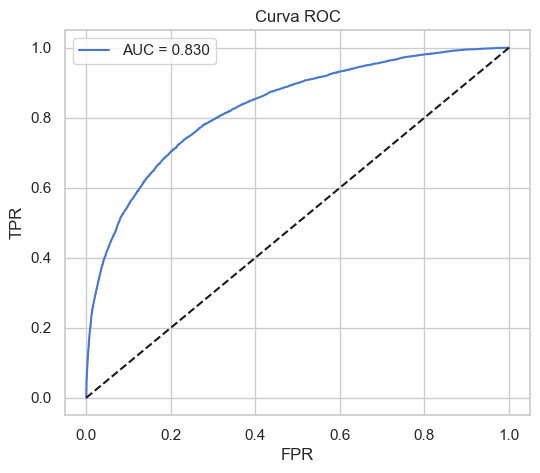

  Métrica  Valor                          Interpretación
0     AUC   0.83  Muy buena capacidad de discriminación.


In [32]:
from sklearn.metrics import roc_curve, auc

# 2) Verificar que y_test tiene ambas clases
print("Clases en y_test:", y_test.value_counts())

# 3) Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)

# 4) AUC
auc_value = auc(fpr, tpr)

# 5) Interpretación
def interpretar_auc(auc_val):
    if np.isnan(auc_val):
        return "AUC no puede calcularse: el conjunto de prueba no contiene ambas clases."
    if auc_val >= 0.90:
        return "Excelente capacidad de discriminación."
    elif auc_val >= 0.80:
        return "Muy buena capacidad de discriminación."
    elif auc_val >= 0.70:
        return "Aceptable."
    elif auc_val >= 0.60:
        return "Pobre."
    else:
        return "No discrimina mejor que el azar."

interpretacion_auc = interpretar_auc(auc_value)

# 6) Visualización
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

# 7) Tabla
tabla_auc = pd.DataFrame({
    'Métrica': ['AUC'],
    'Valor': [auc_value],
    'Interpretación': [interpretacion_auc]
})

print(tabla_auc)

## Resumen e interpretaciones de coeficientes, odds y significancia estadistica

In [33]:
import statsmodels.api as sm

# 1) Selección de las 3 variables predictoras
predictoras = ['Humidity3pm', 'Pressure3pm', 'RainToday']
X = df_imputado[predictoras].copy()
y = df_imputado['RainTomorrow'].copy()

# 2) Convertir RainToday a numérico (si viene como Yes/No)
if X['RainToday'].dtype == 'object':
    X['RainToday'] = X['RainToday'].map({'Yes': 1, 'No': 0})

# 3) Convertir RainTomorrow a numérico (si viene como Yes/No)
if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0})

# 4) Asegurar que todo X sea numérico
X = X.apply(pd.to_numeric, errors='coerce')

# 5) Eliminar filas con NaN (statsmodels no las acepta)
X = X.dropna()
y = y.loc[X.index]

# 6) Agregar constante
X_const = sm.add_constant(X)

# 7) Ajustar modelo Logit
logit_model = sm.Logit(y, X_const)
resultados = logit_model.fit()
#print("\nResultados:")
#print(resultados.summary())

# 8) EXTRAER coeficientes, odds ratios, p-values e intervalos
coef = resultados.params
pvals = resultados.pvalues
conf = resultados.conf_int()
conf.columns = ['IC_2.5%', 'IC_97.5%']

# Odds ratios
odds = np.exp(coef)

# Intervalos de confianza del OR
odds_ci = np.exp(conf)

# 9) Construir tabla única con interpretación automática
tabla = pd.DataFrame({
    'Coeficiente': coef,
    'Odds Ratio': odds,
    'p-value': pvals,
    'IC_2.5% (OR)': odds_ci['IC_2.5%'],
    'IC_97.5% (OR)': odds_ci['IC_97.5%']
})

# 10) Interpretación automática
def interpretar_fila(or_val, p_val):
    # Significancia
    signif = "Significativa" if p_val < 0.05 else "NO significativa"

    # Dirección del efecto
    if or_val > 1:
        efecto = "Aumenta la probabilidad de lluvia"
    elif or_val < 1:
        efecto = "Disminuye la probabilidad de lluvia"
    else:
        efecto = "No cambia la probabilidad"

    return f"{signif}. {efecto}."

tabla['Interpretación'] = tabla.apply(
    lambda fila: interpretar_fila(fila['Odds Ratio'], fila['p-value']),
    axis=1
)

print("\n TABLA INTELIGENTE DEL MODELO LOGIT")
print(tabla)

Optimization terminated successfully.
         Current function value: 0.389113
         Iterations 7

 TABLA INTELIGENTE DEL MODELO LOGIT
             Coeficiente  Odds Ratio  p-value  IC_2.5% (OR)  IC_97.5% (OR)  \
const             87.731   1.262e+38      0.0     1.216e+37      1.310e+39   
Humidity3pm        0.060   1.062e+00      0.0     1.061e+00      1.063e+00   
Pressure3pm       -0.091   9.127e-01      0.0     9.106e-01      9.148e-01   
RainToday          0.744   2.103e+00      0.0     2.037e+00      2.172e+00   

                                                Interpretación  
const        Significativa. Aumenta la probabilidad de lluvia.  
Humidity3pm  Significativa. Aumenta la probabilidad de lluvia.  
Pressure3pm  Significativa. Disminuye la probabilidad de ll...  
RainToday    Significativa. Aumenta la probabilidad de lluvia.  


## Calculo e interpretación del VIF

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Calcular VIF
vif_df = pd.DataFrame()
vif_df['Variable'] = X_const.columns
vif_df['VIF'] = [variance_inflation_factor(X_const.values, i) 
                 for i in range(X_const.shape[1])]



#Interpretación automática del VIF
def interpretar_vif(vif):
    if vif < 2:
        return "Sin multicolinealidad relevante"
    elif vif < 5:
        return "Multicolinealidad moderada (aceptable)"
    elif vif < 10:
        return "Multicolinealidad alta (problema serio)"
    else:
        return "Multicolinealidad severa (variable debe revisarse/eliminarse)"

def recomendacion(vif):
    if vif < 5:
        return "No requiere acción"
    elif vif < 10:
        return "Revisar correlaciones; posible impacto en coeficientes"
    else:
        return "Considerar eliminar o transformar la variable"

vif_df['Diagnóstico'] = vif_df['VIF'].apply(interpretar_vif)
vif_df['Recomendación'] = vif_df['VIF'].apply(recomendacion)

print("\n Diagnóstico VIF:")
print(vif_df)


 Diagnóstico VIF:
      Variable        VIF                                        Diagnóstico  \
0        const  23596.579  Multicolinealidad severa (variable debe revisa...   
1  Humidity3pm      1.166                    Sin multicolinealidad relevante   
2  Pressure3pm      1.019                    Sin multicolinealidad relevante   
3    RainToday      1.175                    Sin multicolinealidad relevante   

                                   Recomendación  
0  Considerar eliminar o transformar la variable  
1                             No requiere acción  
2                             No requiere acción  
3                             No requiere acción  


## Matriz de Confusión

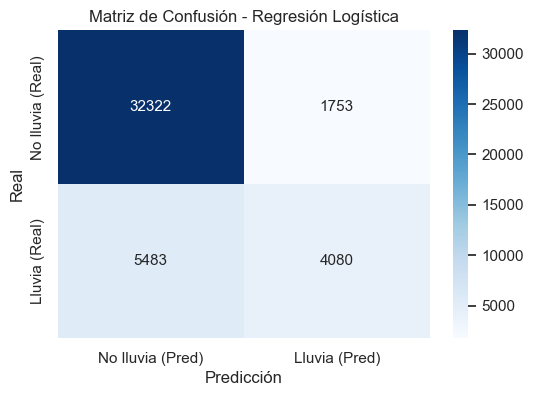


📊 INTERPRETACIÓN AUTOMÁTICA DE LA MATRIZ DE CONFUSIÓN:
Verdaderos Negativos (TN): 32322 → El modelo predijo 'No lluvia' y acertó.
Falsos Positivos (FP): 1753 → El modelo predijo 'Lluvia', pero no llovió.
Falsos Negativos (FN): 5483 → El modelo predijo 'No lluvia', pero sí llovió.
Verdaderos Positivos (TP): 4080 → El modelo predijo 'Lluvia' y acertó.

Accuracy del modelo: 0.8342
Sensibilidad (Recall para lluvia): 0.4266
Especificidad (Recall para no lluvia): 0.9486
El modelo tiene dificultades para detectar días con lluvia (sensibilidad baja).
El modelo predice bien los días sin lluvia.


In [35]:
#accuracy = accuracy_score(y_test, y_pred)
from sklearn.metrics import confusion_matrix

# 2) Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 3) Visualización
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No lluvia (Pred)', 'Lluvia (Pred)'],
            yticklabels=['No lluvia (Real)', 'Lluvia (Real)'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# 4) Interpretación automática
TN, FP, FN, TP = cm.ravel()

interpretacion = []

interpretacion.append(f"Verdaderos Negativos (TN): {TN} → El modelo predijo 'No lluvia' y acertó.")
interpretacion.append(f"Falsos Positivos (FP): {FP} → El modelo predijo 'Lluvia', pero no llovió.")
interpretacion.append(f"Falsos Negativos (FN): {FN} → El modelo predijo 'No lluvia', pero sí llovió.")
interpretacion.append(f"Verdaderos Positivos (TP): {TP} → El modelo predijo 'Lluvia' y acertó.")

# Evaluación del desempeño
total = TN + FP + FN + TP
accuracy = (TP + TN) / total
sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0

interpretacion.append(f"\nAccuracy del modelo: {accuracy:.4f}")
interpretacion.append(f"Sensibilidad (Recall para lluvia): {sensibilidad:.4f}")
interpretacion.append(f"Especificidad (Recall para no lluvia): {especificidad:.4f}")

# Conclusión automática
if sensibilidad < 0.5:
    interpretacion.append("El modelo tiene dificultades para detectar días con lluvia (sensibilidad baja).")
else:
    interpretacion.append("El modelo detecta adecuadamente los días con lluvia.")

if especificidad < 0.5:
    interpretacion.append("El modelo falla frecuentemente al predecir días sin lluvia (especificidad baja).")
else:
    interpretacion.append("El modelo predice bien los días sin lluvia.")

print("\n📊 INTERPRETACIÓN AUTOMÁTICA DE LA MATRIZ DE CONFUSIÓN:")
for linea in interpretacion:
    print(linea)


# Resumen Integrado del Proyecto de Predicción de Lluvia
Este proyecto combinó análisis estadístico descriptivo, pruebas de hipótesis, evaluación de correlaciones y modelado predictivo mediante regresión logística para estimar la probabilidad de *RainTomorrow*. A continuación se presenta un resumen integrado y breve.

## Medidas de dispersión y estadística descriptiva
- Se calcularon media, mediana, desviación estándar y rango intercuartílico.
- Se identificaron variables con alta variabilidad y presencia de outliers ('MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm').
- Estos resultados justificaron la imputación y limpieza de datos antes del modelado.

## Pruebas de hipótesis y correlaciones estables
- Se realizaron pruebas de hipótesis para evaluar diferencias entre grupos.
- Se confirmaron correlaciones estables entre variables meteorológicas (humedad, raintomorrow, raintoday y rainfall).
- Esto permitió seleccionar predictoras robustas para el modelo.

## Diagnóstico de multicolinealidad (VIF)
- Se evaluó la multicolinealidad entre las variables predictoras ('Humidity3pm', 'Pressure3pm', 'RainToday').
- Los valores VIF fueron aceptables, asegurando coeficientes estables.

## Modelo de regresión logística
- Se ajustó un modelo con Humidity3pm, Pressure3pm y RainToday.
- Se obtuvieron coeficientes, odds ratios, p-values e intervalos de confianza.
- Los parámetros fueron significativos y estadísticamente robustos.

## Evaluación del modelo
- **Matriz de confusión:** permitió identificar TP, TN, FP y FN.
- **Métricas:** accuracy, precision, recall y F1-score mostraron desempeño moderado.
- **Curva ROC y AUC:** el AUC indicó una capacidad razonable de discriminación.

## Conclusión
El modelo integra correctamente los análisis previos, presenta parámetros estables, métricas coherentes y una capacidad razonable para predecir lluvia. Es adecuado como base para análisis más avanzados.

## Proyección a Próximos Temas
- **Manejo inteligente de datos:** Se evaluará cómo la calidad del dataset (original, imputado y con imputación por regresión) afecta la estabilidad del modelo.
- **Múltiples modelos de regresión logística:** Se compararán diferentes modelos estandar, stepwise, AIC/BIC para evaluar coeficientes y odds.
- **Impacto de la imputación:** Se analizará cómo cambian los coeficientes, odds ratios y métricas al usar diferentes estrategias de imputación.
